## Fairness, Accountability, Transparency and Ethics Course (FATE)
## Universitat Pompeu Fabra (UPF)
### Academic Year 2026-2027
### Author: Morgan Gallagher (morgan.gallagher@upf.edu)
*** Based on the original exercises made by Ashwin Singh (ashwin.singh@tuwien.ac.at) ***

Submission date: March 10th at 11:59pm on Aula Global

Remember to submit this notebook **individually**.

The questions in this notebook are evaluated out of 100 points but your final grade will be out of 10 points.

# LAB 3: Algorithmic Fairness in Classification using AI Fairness 360

<font size="+1">This lab introduces how to use the bias mitigation tools provided in AI Fairness 360.

> *AIF360 is an extensible open-source library containing techniques developed by the research community to help detect and mitigate bias in machine learning models throughout the AI application lifecycle.*

First we will review ROC and Error Detection curves, then we will demo some of the pre-processing, in-processing, and post-processing tools offered by AIF360. After the demo you will have the chance to use an intervention improve model performance on a dataset of your choice. </font>

Author: <font color="blue">Your name here</font>

E-mail: <font color="blue">Your e-mail here</font>

Date: <font color="blue">The current date here</font>

# Installs & Imports

In [64]:
!pip install aif360
!pip install 'aif360[Reductions]'
!pip install 'aif360[inFairness]'

In [65]:
# change your python version to fit the paths

!wget https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data -P /usr/local/lib/python3.12/dist-packages/aif360/data/raw/german
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.doc -P /usr/local/lib/python3.12/dist-packages/aif360/data/raw/german

In [66]:
# Pre-Processing Imports
from aif360.algorithms.preprocessing.optim_preproc import OptimPreproc
from aif360.algorithms.preprocessing.optim_preproc_helpers.data_preproc_functions import load_preproc_data_german
from aif360.algorithms.preprocessing.optim_preproc_helpers.distortion_functions import get_distortion_german
from aif360.algorithms.preprocessing.optim_preproc_helpers.opt_tools import OptTools
from aif360.algorithms.preprocessing.reweighing import Reweighing

# In-Processing Imports
from aif360.algorithms.inprocessing.exponentiated_gradient_reduction import ExponentiatedGradientReduction

# Post-Processing Imports
from aif360.algorithms.postprocessing.calibrated_eq_odds_postprocessing import CalibratedEqOddsPostprocessing

# Other Imports
from aif360.datasets import GermanDataset, StructuredDataset
from aif360.metrics import ClassificationMetric

In [67]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import *

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

import warnings

In [68]:
warnings.filterwarnings(action="ignore")
sns.set_theme(style='whitegrid')

# Data

> [Hans Hofmann. 1994. Statlog (German Credit Data). UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data)

We will be working with the German Credit Data dataset. It contains 1000 records of loan applications. Each record is classified as good or bad credit risks.

A detailed description for all attributes in data is available [here](https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data), under *Additional Variable Information*.

In [69]:
data = GermanDataset()
data.labels %= 2 # 0 if credit score is bad, else 1

dataset, info = data.convert_to_dataframe()
dataset.head()

,month,credit_amount,investment_as_income_percentage,residence_since,age,number_of_credits,people_liable_for,sex,status=A11,status=A12,...,housing=A153,skill_level=A171,skill_level=A172,skill_level=A173,skill_level=A174,telephone=A191,telephone=A192,foreign_worker=A201,foreign_worker=A202,credit
0,6.0,1169.0,4.0,4.0,1.0,2.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0
1,48.0,5951.0,2.0,2.0,0.0,1.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
2,12.0,2096.0,2.0,3.0,1.0,1.0,2.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
3,42.0,7882.0,2.0,4.0,1.0,1.0,2.0,1.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0
4,24.0,4870.0,3.0,4.0,1.0,2.0,2.0,1.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0


# EDA

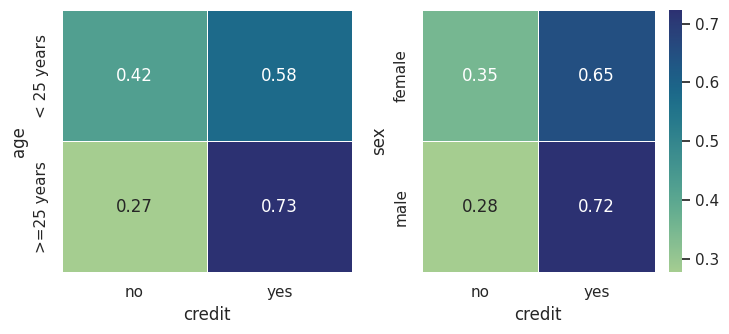

In [70]:
# side by side comparison plots
fig, (ax1, ax2) = plt.subplots(1, 2)

fig.set_figheight(3.5)
fig.set_figwidth(7.5)

_ = dataset.copy()
_.age = _.age.map(lambda age: {0:"< 25 years",1:">=25 years"}[age])
_.sex = _.sex.map(lambda sex: {0:"female",1:"male"}[sex])
_.credit = _.credit.map(lambda credit: {1:"yes", 0:"no"}[credit])

# age heatmap
sns.heatmap(
    data = pd.crosstab(
        _.age,
        _.credit,
        normalize="index"
    ),
    annot = True,
    fmt = ".2f",
    ax = ax1,
    linewidth=.5,
    cmap = "crest",
    cbar=False
)

# sex heatmap
sns.heatmap(
    data = pd.crosstab(
        _.sex,
        _.credit,
        normalize="index"
    ),
    annot=True,
    fmt=".2f",
    ax = ax2,
    linewidth=.5,
    cmap = "crest"
)

plt.tight_layout()
plt.show()

In [71]:
_.groupby(['age','sex']).credit.value_counts(normalize=True)

age         sex     credit
< 25 years  female  yes       0.552381
                    no        0.447619
            male    yes       0.611765
                    no        0.388235
>=25 years  female  yes       0.697561
                    no        0.302439
            male    yes       0.738843
                    no        0.261157
Name: proportion, dtype: float64

##Underlying Biases **[8 pts]**

By now, you should understand the machine learning workflow and how bias can appear in simple linear regression models. A commonly proposed bias mitigation technique is to collect more data and improve its quality. While this can lead to better models, data quality alone is not always sufficient. Bias can be introduced at any stage of the machine learning pipeline, from data collection to model deployment.

> *Harini Suresh and John Guttag. 2021. A framework for understanding sources of harm throughout the machine learning life cycle. Equity and Access in Algorithms, Mechanisms, and Optimization (October 2021), 1–9. http://dx.doi.org/10.1145/3465416.3483305*

> *James L. Cross, Michael A. Choma, and John A. Onofrey. 2024. Bias in medical AI: Implications for clinical decision-making. PLOS Digital Health 3, 11 (November 2024). http://dx.doi.org/10.1371/journal.pdig.0000651*

**[5 pts]** For each stage of the machine learning pipeline listed below, briefly describe one possible source of bias and provide one example.

1.   Data collection
2.   Data pre-processing
3.   Model selection
4.   Model evaluation
5.   Model deployment


**[Answer]**

**[3 pts]** Comment on potential underlying biases in the German Credit dataset. List the privileged and unprivileged groups in your response. You must support your answer with the data from above.

**[Answer]**

# Modeling Loan Approval

## Train-Test Split

The data is split into train set and test set in an 80-20 ratio, and shuffled for randomization.

In [72]:
train, test = data.split([0.8], shuffle=True, seed=42)

base_train, _ = train.convert_to_dataframe()
base_test, _ = test.convert_to_dataframe()

## Preprocessing

In [73]:
numerical = ["month", "credit_amount", "investment_as_income_percentage",
             "residence_since", "number_of_credits", "people_liable_for"]

scaler = StandardScaler()

base_train[numerical] = scaler.fit_transform(base_train[numerical])
base_test[numerical] = scaler.transform(base_test[numerical])

## Model Training and Evaluation

In [74]:
def evaluate(model,X_test,y_test):
    """
    Evaluates the model and produces confusion matrix.

    Args:
        model: model to fit and evaluate.
        X_test: test set feature matrix.
        y_test: test set labels.
    """
    y_pred = model.predict(X_test)

    acc = accuracy_score(
        y_true = y_test,
        y_pred = y_pred
    )

    ConfusionMatrixDisplay.from_predictions(
        y_true = y_test,
        y_pred = y_pred,
        cmap = "crest",
        colorbar=False
    )

    plt.title(f"Accuracy: {round(acc,2)}")
    plt.grid(False)
    plt.show()

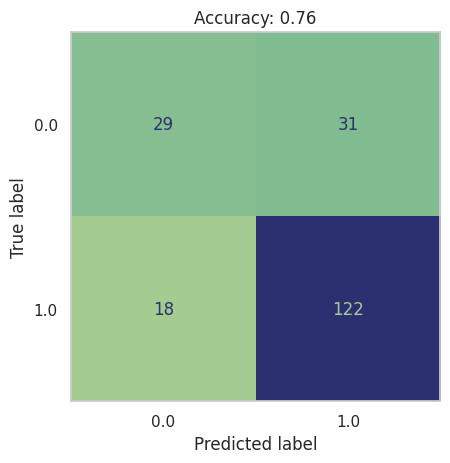

In [75]:
X_train, y_train = base_train[info["feature_names"]], base_train["credit"]
X_test, y_test = base_test[info["feature_names"]], base_test["credit"]

base_model = LogisticRegression()
base_model = base_model.fit(X_train, y_train)

evaluate(base_model,X_test,y_test)

# ROC Curves

Each point in the ROC curve corresponds to a particular classification threshold $\theta$ for a model f, such that if $f(x) \geq \theta \implies \widehat{y} = 1$, and $0$ otherwise. By plotting false-positive and true-positive rates for each $\theta$ we can study the trade-offs for different thresholds $\theta$

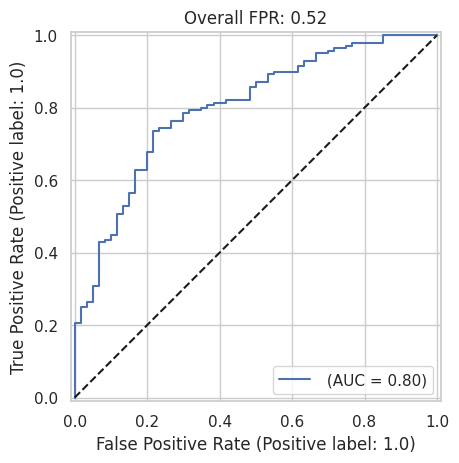

In [76]:
def plot_roc(model,X,y,ax=None,label=""):
    """
    Plot the ROC curve for a classification model.

    Args:
        model: model to fit and evaluate.
        X: test set feature matrix.
        y: test set labels.
        ax: axis to plot on.
        label: label to add to the plot title.
    """
    y_pred = model.predict(X)
    tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()
    fpr = (fp / (tn + fp))

    RocCurveDisplay.from_estimator(
        model,
        X,
        y,
        ax=ax,
        plot_chance_level=True,
        chance_level_kw = {"label":None},
        name=""
    )

    if ax is not None:
        ax.set_title(
            f"{label} | FPR: {round(fpr,2)}"
        )
    else:
        plt.title(
            f"Overall FPR: {round(fpr,2)}"
        )

plot_roc(base_model,X_test,y_test)
plt.show()

## Groupwise **[3 pts]**

Loan Approval is an **assistive** intervention - therefore it is interesting to see for which groups, the model affords higher **false-positive rates** i.e., loan approval rates for individuals who will not pay it back. What do they indicate?

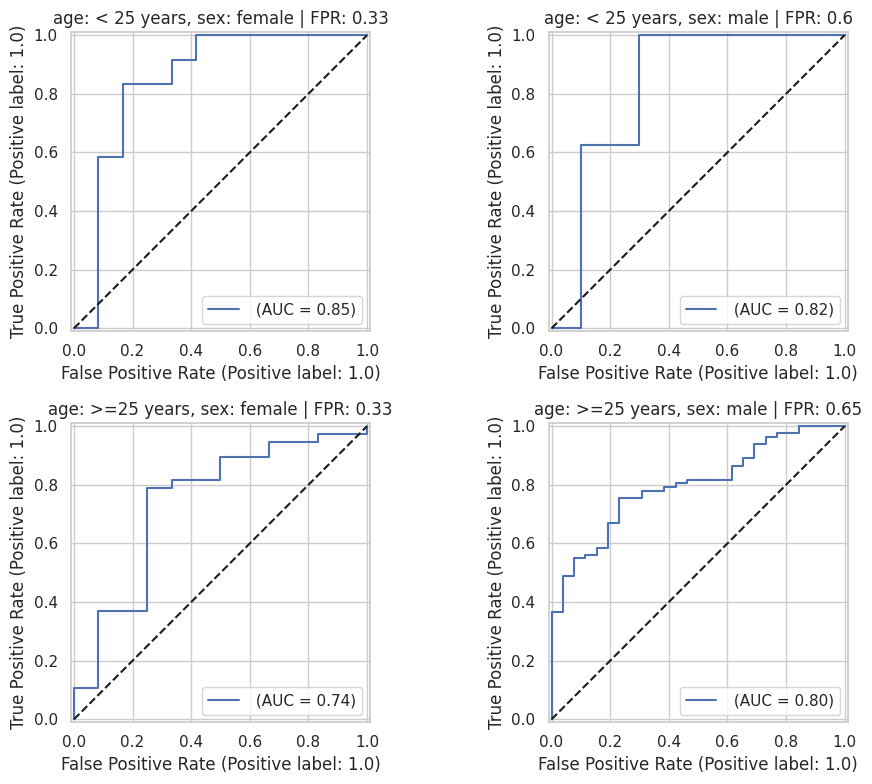

In [77]:
def plot_roc_by_group(model,test,info):
    """
    Plot the ROC curves for sex and age groups.

    Args:
        model: fitted model to evaluate.
        test: test dataset.
        info: dataset attributes.
    """
    fig, axes = plt.subplots(2, 2)
    fig.set_figheight(8)
    fig.set_figwidth(10)

    grouped = test.groupby(["age","sex"])

    for group in grouped.groups.keys():
        group_df = grouped.get_group(group)
        X, y = group_df[info["feature_names"]], group_df["credit"]

        age_label = "< 25 years" if not group[0] else ">=25 years"
        sex_label = "female" if not group[1] else "male"
        label = f"age: {age_label}, sex: {sex_label}"

        ax = axes[int(group[0])][int(group[1])]

        plot_roc(model,X,y,label=label,ax=ax)

    plt.tight_layout()
    plt.show()

plot_roc_by_group(base_model, base_test, info)

**[3 pts]** For each group, interpret the results by evaluating the ROC curve and commenting on the false positive rate.

**[Answer]**

# Error Detection Curve

Similar to ROC, each point in the error-detection curve corresponds to a particular classification threshold $\theta$ for a model f, such that if $f(x) \geq \theta \implies \widehat{y} = 1$, and $0$ otherwise. By plotting false-positive and false-negative rates for each $\theta$ we can study the trade-offs for different thresholds $\theta$.

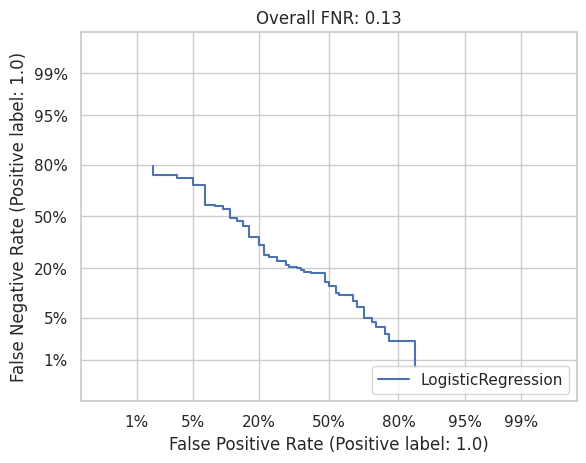

In [78]:
def plot_edc(model,X,y,ax=None,label=""):
    """
    Plot the EDC curve for a classification model.

    Args:
        model: fitted model to evaluate.
        X: test set feature matrix.
        y: test set labels.
        ax: axis to plot on.
        label: label to add to the plot title.
    """
    yp = model.predict(X)
    tn, fp, fn, tp = confusion_matrix(y, yp).ravel()
    fnr = (fn / (tp + fn))

    DetCurveDisplay.from_estimator(
        model,
        X,
        y,
        ax=ax
    )

    if ax is not None:
        ax.set_title(
            f"{label} | FNR: {round(fnr,2)}"
        )
    else:
        plt.title(
            f"Overall FNR: {round(fnr,2)}"
        )


plot_edc(base_model,X_test,y_test)
plt.show()

## Groupwise **[6 pts]**

This is more relevant for **assistive** interventions, as not approving loans for individuals who will pay it back **(false-negatives)** is a worse outcome than the opposite. What do different **(false-negative rates)** by groups indicate?

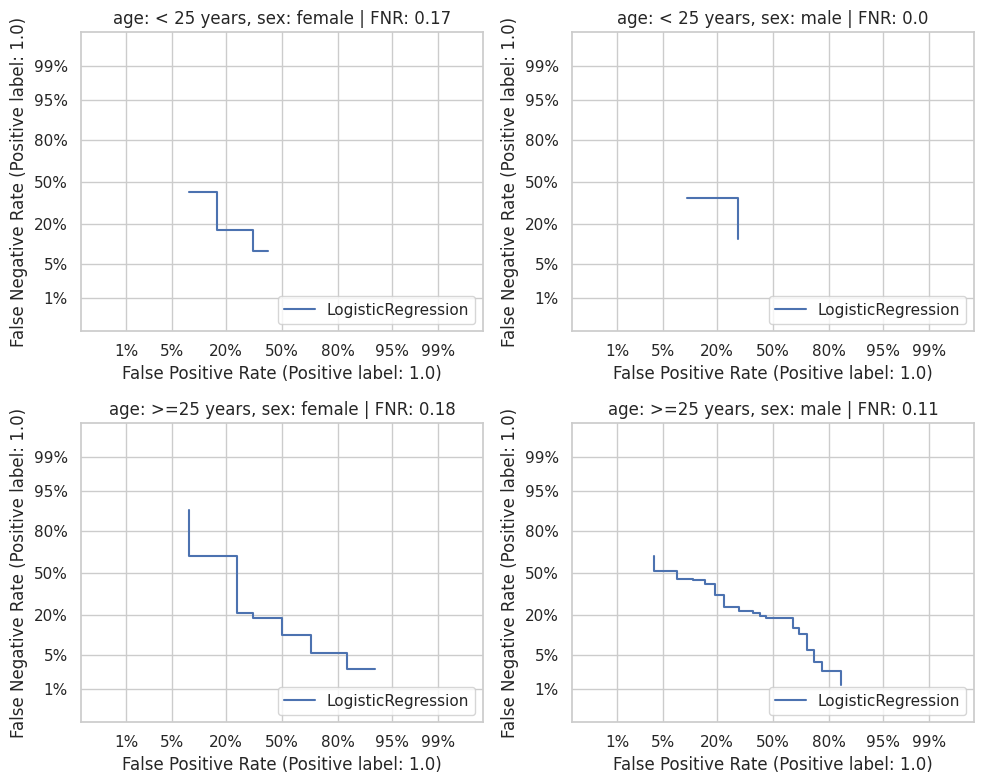

In [79]:
def plot_edc_by_group(model,test,info):
    """
    Plot the EDC curves for sex and age groups.

    Args:
        model: fitted model to evaluate.
        test: test dataset.
        info: dataset attributes.
    """
    fig, axes = plt.subplots(2, 2)
    fig.set_figheight(8)
    fig.set_figwidth(10)

    grouped = test.groupby(["age","sex"])
    groups = grouped.groups.keys()

    for group in groups:
        group_df = grouped.get_group(group)
        X, y = group_df[info["feature_names"]], group_df["credit"]

        age_label = "< 25 years" if not group[0] else ">=25 years"
        sex_label = "female" if not group[1] else "male"
        label = f"age: {age_label}, sex: {sex_label}"

        ax = axes[int(group[0])][int(group[1])]

        plot_edc(model,X,y,ax=ax,label=label)

    plt.tight_layout()
    plt.show()

plot_edc_by_group(base_model,base_test,info)

 **[3 pts]** For all groups, should the bank minimize false positives (Type I errors) or minimize false negatives (Type II errors)? Make arguments for both cases.

**[Answer]**

**[3 pts]** For each group, interpret the results by evaluating the ROC curve and commenting on the false positive rate. Which group does the model benefit the most? The least?

**[Answer]**

# Fairness Metrics

**False Negative Rate Ratio** (FNR ratio) compares the error of omission between two groups. A ratio of 1.0 indicates parity. A ratio of 2.0 indicates the model is twice as likely to misclassify a positive case as negative in the unprivileged group compared to the privileged one.

1. FNR Ratio $= \frac{FNR_{A=\text{unprivileged}}}{FNR_{A=\text{privileged}}}$

**False Negative Rate Difference** (FNR diff) measures the absolute difference in false negative rates between two groups. In other words, it indicates how much more frequently one group's positive cases are misclassified as negative compared to the other group.

2. FNR Diff $ = FNR_{A=\text{unprivileged}} - FNR_{A=\text{privileged}}$

**Disparate Impact** (DI) measures the ratio of positive outcome rates between the privileged and unprivileged groups. This metric captures disparities in favorable outcomes (i.e., whether one group receives more favorable predictions compared to the other).

3. DI $= \frac{P(\;\widehat{Y}=1\;|\;A=\text{unprivileged}\;)}{P(\;\widehat{Y}=1\;|\;A=\text{privileged}\;)}$


More generally, metrics **1, 2** are variants of error rate ratio, and error rate difference.

In [80]:
def fairness_metrics(model,test,info):
    """
    Calculates FNR ratio, FNR difference, and DI for protected attributes.

    Args:
        model: model to fit.
        test: test dataset.
        info: dataset attributes.
    """

    protected_attributes = info['protected_attribute_names']
    num_attributes = len(protected_attributes)
    unprivileged = info['unprivileged_protected_attributes']
    privileged = info['privileged_protected_attributes']

    for i in range(num_attributes):
        attribute = protected_attributes[i]
        privileged_attribute = privileged[i][0]
        unprivileged_attribute = unprivileged[i][0]

        print(f"Attribute: {attribute}")

        privileged_subset = test[test[attribute]==privileged_attribute]
        X_pr = privileged_subset[info['feature_names']]
        y_pr = privileged_subset[info['label_names']]
        y_pred_pr = model.predict(X_pr)
        # Note: there are cases where to you should make variable
        # names longer for readability. Depending on your group's
        # guidelines you may be able to exceed 79 code chars per line.
        tn_pr, fp_pr, fn_pr, tp_pr = (
            confusion_matrix(y_pr,y_pred_pr).ravel()
        )
        fnr_pr = (fn_pr / (tp_pr + fn_pr))

        unprivileged_subset = test[test[attribute]==unprivileged_attribute]
        X_unpr = unprivileged_subset[info['feature_names']]
        y_unpr = unprivileged_subset[info['label_names']]
        y_pred_unpr = model.predict(X_unpr)
        tn_unpr, fp_unpr, fn_unpr, tp_unpr = (
            confusion_matrix(y_unpr,y_pred_unpr).ravel()
        )
        fnr_unpr = fn_unpr / (tp_unpr + fn_unpr)

        fnr_ratio = fnr_unpr / fnr_pr
        fnr_diff = fnr_unpr - fnr_pr
        disparate_impact = (
            sum(y_pred_unpr) / len(y_unpr)) / (sum(y_pred_pr) / len(y_pr)
        )

        print(
            f"""
              False Negative Rate Ratio       : {fnr_ratio:.2f}\n
              False Negative Rate Difference  : {fnr_diff:.2f}\n
              Disparate Impact                : {disparate_impact:.2f}\n
            """
        )


In [81]:
def fairness_metrics_from_predictions(test,pred,unprivileged_groups,label):
    """
    Plots confusion matrix and prints fairness metrics.

    Args:
        test: test dataset.
        pred: predictions.
        unprivileged_groups: unprivileged groups.
        label: label name.
    """
    attribute, unpr_val = unprivileged_groups.popitem()

    test_df, _ = test.convert_to_dataframe()
    pred_df, _ = pred.convert_to_dataframe()

    overall_accuracy = accuracy_score(
        y_true = test_df[label].values,
        y_pred = pred_df[label].values
    )

    ConfusionMatrixDisplay.from_predictions(
        y_true = test_df[label].values,
        y_pred = pred_df[label].values,
        cmap = "crest",
        colorbar = False
    )
    plt.grid(False)

    y_pr = test_df[test_df[attribute] != unpr_val][label].values
    y_pred_pr = pred_df[pred_df[attribute] != unpr_val][label].values

    y_unpr = test_df[test_df[attribute] == unpr_val][label].values
    y_pred_unpr = pred_df[pred_df[attribute] == unpr_val][label].values

    tn_pr, fp_pr, fn_pr, tp_pr = confusion_matrix(y_pr, y_pred_pr).ravel()
    fnr_pr = fn_pr / (tp_pr + fn_pr)

    tn_unpr, fp_unpr, fn_unpr, tp_unpr = (
        confusion_matrix(y_unpr, y_pred_unpr).ravel()
    )
    fnr_unpr = fn_unpr / (tp_unpr + fn_unpr)

    fnr_ratio = fnr_unpr / fnr_pr
    fnr_diff = fnr_unpr - fnr_pr
    disparate_impact = (
        (y_pred_unpr.sum() / len(y_unpr)) / (y_pred_pr.sum() / len(y_pr))
    )

    print(
        f"""
          Accuracy                        : {overall_accuracy:.2f}\n
          False Negative Rate Ratio       : {fnr_ratio:.2f}\n
          False Negative Rate Difference  : {fnr_diff:.2f}\n
          Disparate Impact                : {disparate_impact:.2f}\n
        """
    )

## Metrics for Loan Approval **[3 pts]**

In [82]:
fairness_metrics(
    base_model,
    base_test,
    info
)

Attribute: sex

              False Negative Rate Ratio       : 1.80

              False Negative Rate Difference  : 0.08

              Disparate Impact                : 0.80

            
Attribute: age

              False Negative Rate Ratio       : 0.75

              False Negative Rate Difference  : -0.03

              Disparate Impact                : 0.84

            


**[3 pts]** Interpret the results of the logistic model. You **must** use fairness metrics in your response.

**[Answer]**

#AIF360 Demo

First and foremost I would recommend looking at the [documentation](https://aif360.readthedocs.io/en/latest/Getting%20Started.html) for this package. This package is well documented and relatively easy to read. The [source code](https://github.com/Trusted-AI/AIF360/tree/main) may also be helpful to you.

AIF360 splits the machine learning workflow into three general points, **pre-processing, in-processing, and post-processing**. Testing and bias mitigation tools are built around these three points.

*   **Pre-processing:** transforms the data before model training (e.g. reweighing).
*   **In-processing:** modifies training algorithm itself to incorporate fairness as an objective (e.g. adversarial debiasing).
*   **Post-processing:** adjusts a fitted model's predictions to achieve a certain metric (e.g. equalized odds).



## Scenario

Suppose you are hired as a **Risk Analyst** at a Bank, where you are responsible for approving loans, given an individual's credit history, amount, purpose, investments among other attributes.

Based on your observations about the underlying biases, and model performance on different fairness metrics, you decide to experiment with different interventions to mitigate undesired outcomes.

## Preprocessing Intervention **[10 pts]**

### Optimized PreProc
---
> [Flavio P. Calmon, Dennis Wei, Bhanukiran Vinzamuri, Karthikeyan Natesan Ramamurthy, and Kush R. Varshney. 2017. Optimized pre-processing for discrimination prevention. In Proceedings of the 31st International Conference on Neural Information Processing Systems (NeurIPS'17)](https://papers.nips.cc/paper_files/paper/2017/file/9a49a25d845a483fae4be7e341368e36-Paper.pdf).

This intervention transforms the data $A,X,Y \rightarrow A,\widehat{X},\widehat{Y}$ while ensuring the following:
1.   For each protected group $a \in A$, the dependence of $\widehat{Y}$ on $a$ is bounded. Further, for any two protected groups $a_1,a_2 \in A$, the difference between the dependencies of $\widehat{Y}$ on $a_1,a_2$ is also bounded.
> *The transformed data tries to satisfy independence as closely as possible.*
2. Expected pointwise distortions in the transformation are minimal
> *A person with a really low chance of approval in the original data does not suddenly have a great credit rating in the transformed data.*
3. Differences (*KL-divergence*) in the probability distribution underlying the data before and after the transformation are bounded.
> *A person with a really rare set of attributes in the original data is not suddenly more common in the transformed data.*
---
### Instance Reweighing
---
[Kamiran, F., Calders, T. Data preprocessing techniques for classification without discrimination. Knowledge & Information Systems (2012).](https://link.springer.com/article/10.1007/s10115-011-0463-8)

Reweighs each instance before classification to remove the dependence of the class variable on sensitive attribute, or more specifically, to ensure that $P(Y=1,A=a) = P(Y=1) \times P(A=a)$, and vice versa for $Y=0$.



In [83]:
def apply_optim_preproc(params,train,test):
    """
    Apply optimized preprocessing from AIF360.

    Args:
        params: parameters for the intervention.
        train: training dataset.
        test: testing dataset.
    """
    OP = OptimPreproc(**params)
    OP = OP.fit(train)
    transf_train = OP.transform(train, transform_Y=True)
    transf_test = OP.transform(test, transform_Y=True)
    train = train.align_datasets(transf_train)
    test = test.align_datasets(transf_test)
    return train,test


def apply_reweighing(params,train,test):
    """
    Apply reweighing from AIF360.

    Args:
        params: parameters for the intervention.
        train: training dataset.
        test: testing dataset.
    """
    RW = Reweighing(**params)
    RW.fit(train)
    train = RW.transform(train)
    test = RW.transform(test)
    return train, test

In [55]:
# some preprocessing methods only use a subset of attributes
dataset = load_preproc_data_german(['sex','age'])

# ensure same split as base
pre_train, pre_test = dataset.split([0.8], shuffle=True, seed=42)

# you can play around with parameters to achieve desired fairness properties
params = {
    "optimizer":OptTools,
    "privileged_groups":[{'sex': 1},{'age': 1}],
    "unprivileged_groups":[{'sex': 0},{'age': 0}],
    "optim_options":{
        "distortion_fun": get_distortion_german,
        "epsilon": 0.05,
        "clist": [0.99, 1.99, 2.99],
        "dlist": [.1, 0.05, 0]
    }
}
pre_train, pre_test = apply_optim_preproc(params,pre_train,pre_test)

# Uncomment to use Instance Reweighing
# params = {
#     "privileged_groups":[{'age': 1}],
#     "unprivileged_groups":[{'age': 0}],
# }
# pre_train, pre_test = apply_reweighing(params,train,test)

pre_train.labels %= 2
pre_train, info = pre_train.convert_to_dataframe()

pre_test.labels %= 2
pre_test, _ = pre_test.convert_to_dataframe()

X_train, y_train = pre_train[info["feature_names"]], pre_train["credit"]
X_test, y_test = pre_test[info["feature_names"]], pre_test["credit"]

pre_model = LogisticRegression()
pre_model = pre_model.fit(X_train, y_train)

Optimized Preprocessing: Objective converged to 0.000000


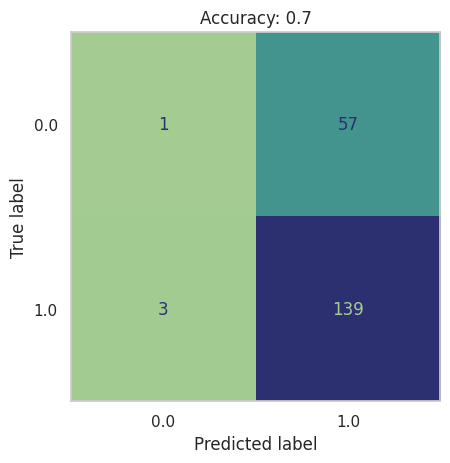

Attribute: sex

              False Negative Rate Ratio       : 0.81

              False Negative Rate Difference  : -0.00

              Disparate Impact                : 0.99

            
Attribute: age

              False Negative Rate Ratio       : 0.00

              False Negative Rate Difference  : -0.03

              Disparate Impact                : 1.03

            


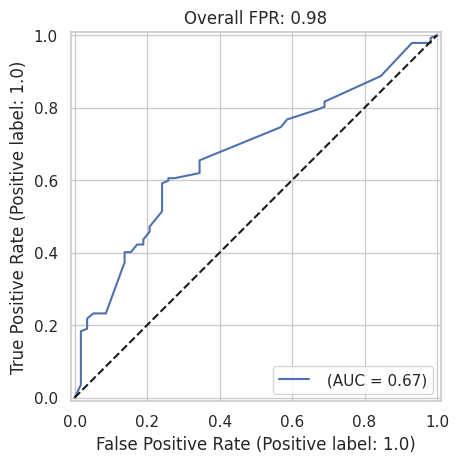

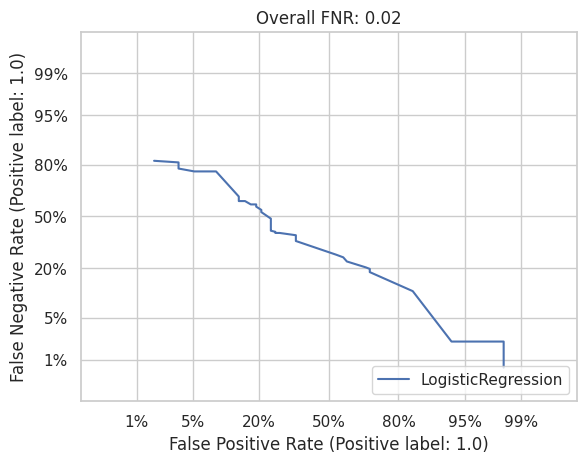

In [56]:
evaluate(pre_model,X_test,y_test)

fairness_metrics(
    pre_model,
    test = pre_test,
    info = info
)

plot_roc(pre_model,X_test,y_test)
plot_edc(pre_model,X_test,y_test)

**[5 pts]** Based on the new metrics, do you think this is a good model? If yes, why? and if not, what can be improved?

**[Answer]**

**[5 pts]** **Repeat** the same exercise using **Instance Reweighing** method for both **sex** and **age** as protected attributes. Are the results better or worse?

In [57]:
# your code here

**[Answer]**

## In-Processing Intervention **[10 pts]**

### Exponentiated Gradient Reduction
---

Agarwal, A., Beygelzimer, A., Dudik, M., Langford, J. &amp; Wallach, H.. (2018). A Reductions Approach to Fair Classification. <i>Proceedings of the 35th International Conference on Machine Learning</i>, in <i>Proceedings of Machine Learning Research</i> 80:60-69 Available from https://proceedings.mlr.press/v80/agarwal18a.html.

This intervention trains the classifier subject to constraints which ensure **demographic-parity / equalized-odds** for all combinations of protected attributes in data. Recall that a classifier $h$ satisfies:

> **Demographic Parity** if $h \perp \!\!\! \perp A$ i.e., $P[\;h(x)=\widehat{y}\;|\;A=a\;] = P[\;h(x)=\widehat{y}\;]\;\;\forall\;a \in A $

> **Equalized Odds** if $h \perp \!\!\! \perp A\;|\;Y$ i.e., $P[\;h(x)=\widehat{y}\;|\;A=a,\;Y=y\;] = P[\;h(x)=\widehat{y}\;|\;Y=y\;]\;\;\forall\;a \in A,\;y \in Y$


          Accuracy                        : 0.72

          False Negative Rate Ratio       : 1.20

          False Negative Rate Difference  : 0.03

          Disparate Impact                : 0.93

        


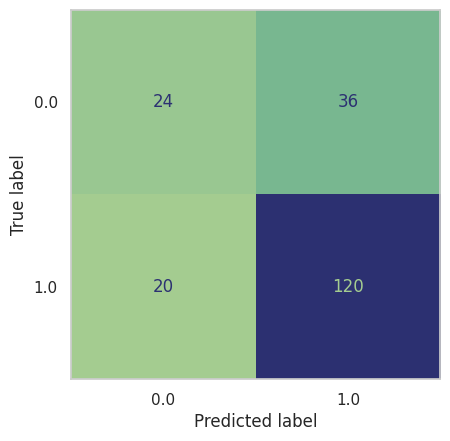

In [58]:
# ensure same split as base
in_train, in_test = data.split([0.8], shuffle=True, seed=42)

in_model = ExponentiatedGradientReduction(
    estimator = LogisticRegression(solver='lbfgs'),
    constraints = "DemographicParity", # can also be EqualizedOdds
    drop_prot_attr = True
)
in_model = in_model.fit(in_train)
classified_test = in_model.predict(in_test)

fairness_metrics_from_predictions(
    test = in_test,
    pred = classified_test,
    unprivileged_groups = {"sex":0}, # can also be age
    label = info["label_names"]
)

**[5 pts]**
Do you think this is a good model? If yes, why? and if not, what can be improved?

**[Answer]**

**[5 pts]** **Repeat** the same exercise for **age** as the protected attribute. Are the results better or worse?

In [59]:
# your code here

**[Answer]**

## Post-Processing Intervention **[10 pts]**

### Calibrated Odds-Equalizing
---
[Geoff Pleiss, Manish Raghavan, Felix Wu, Jon Kleinberg, and Kilian Q. Weinberger. 2017. On fairness and calibration. In Proceedings of the 31st International Conference on Neural Information Processing Systems (NeurIPS'17)](https://papers.nips.cc/paper_files/paper/2017/file/b8b9c74ac526fffbeb2d39ab038d1cd7-Paper.pdf)

> This intervention optimizes over calibrated classifier score outputs to find probabilities with which to change output labels to ensure equalized odds.

In [60]:
# ensure same split as base
post_train, post_test = data.split([0.8], shuffle=True, seed=42)

# create validation set
post_train, post_val = post_train.split([0.75], shuffle=True, seed=42)

# create spare copies for prediction and calibration
post_val_orig = post_val.copy(deepcopy=True)
post_val_pred = post_val.copy(deepcopy=True)

post_train, info = post_train.convert_to_dataframe()
post_val, _ = post_val.convert_to_dataframe()

X_train, y_train = (post_train[info["feature_names"]],
                    post_train[info["label_names"]])
X_val, y_val = (post_val[info["feature_names"]],
                post_val[info["label_names"]])

_model = LogisticRegression()
_model = _model.fit(X_train, y_train)
_model.classes_

array([0., 1.])


          Accuracy                        : 0.82

          False Negative Rate Ratio       : nan

          False Negative Rate Difference  : 0.00

          Disparate Impact                : 0.68

        


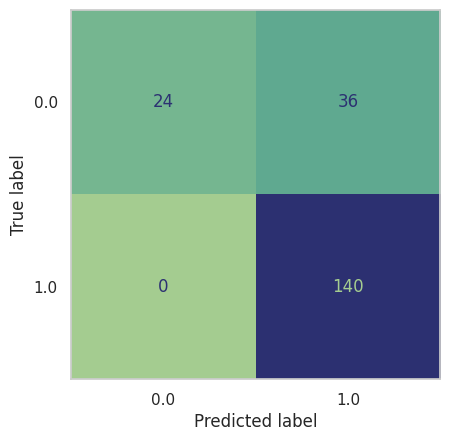

In [61]:
post_val_pred.scores = _model.predict_proba(X_val)[:,1] # positive class
post_val_pred.labels = np.array([[l] for l in _model.predict(X_val)])

post_model = CalibratedEqOddsPostprocessing(
    unprivileged_groups = [{"sex":0}], # can also be age
    privileged_groups = [{"sex":1}], # can also be age
    cost_constraint = "fnr",

)

post_model = post_model.fit(post_val_orig, post_val_pred)

pred_test = post_model.predict(post_test)
pred_test.labels %= 2

fairness_metrics_from_predictions(
    test = post_test,
    pred = pred_test,
    unprivileged_groups = {"sex":0}, # can also be age
    label = info["label_names"]
)

**[5 pts]**
Do you think this is a good model? If yes, why? and if not, what can be improved?

**[Answer]**

**[5 pts]** **Repeat** the same exercise for **age** as the protected attribute. Are the results better or worse?

In [62]:
# your code here

**[Answer]**

#Mini Project

##Mini Project Directions **[50 pts]**.

Now it is your turn to explore a dataset of your choice and implement an intervention from AIF360. You must:

1.   **[2 pts]** Select a dataset and a protected attribute (see slides for examples).
2.   **[5 pts]** Identify the privileged and unprivileged groups.
3.   **[5 pts]** Select appropriate fairness metrics.
4.   **[14 pts]** Train a classifier and evaluate its performance using the selected fairness metrics.
5.   **[14 pts]** Apply one intervention to improve the model's performance with respect to the fairness metrics.
6. **[10 pts]** In at least four sentences, answer the following questions: Would you recommend that this model be deployed today to make decisions? If so, why? If not, what improvements would you make?

To receieve points you must **fully explain and justify** the metrics, models, and interventions used. For example, if you decide to use False Negative Rate Ratio as a fairness metric, you must explain **why** you chose it.

You may use the interventions introduced in this practice, but you are also encouraged to experiment with other interventions offered by the library. Again, I will point you to AIF360's [documentation](https://aif360.readthedocs.io/en/latest/Getting%20Started.html).

If your intervention does not improve performance, that is ok. The goal of this section is to demonstrate your understanding of how to apply the interventions and interpret the results. Make sure to explain why you think performance did not improve.



In [63]:
# your code here

#Declaration

<font size="+1">I hereby declare that, except for the code provided by the course instructors, all of my code, report, and figures were produced by myself.</font>

<font size="+1">In the case you have used **Generative AI** for assistance, please complete the following.

I have used the Generative AI tool **[tool]** in the following way (be specific): </font>

<font color="blue">Your name here</font>